In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import StandardScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D2 in response_OUS
data = list(OUS_D2['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D2 with response_OUS
clinical_train = pd.merge(OUS_D2, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D2['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D2 in response_MAASTRO
data = list(MAASTRO_D2['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D2 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D2, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event
0,1,0.765178,0.610062,30.504395,50.002093,52.886671,58.000000,47.759816,58.864251,38067.208333,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,0.776540,0.504616,21.069386,41.753334,44.922155,44.294469,44.147480,48.723711,17870.791667,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,0.697164,0.478604,21.238275,44.375483,48.466483,45.891176,37.656341,48.969378,17426.500000,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,44.43,1.0
3,4,0.574636,0.446059,20.570459,46.115989,42.544095,47.507894,33.837849,55.226805,12463.791667,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,37.20,1.0
4,6,0.633419,0.480378,26.130155,54.394967,66.030296,56.320511,45.398238,67.089492,28300.125000,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,0.882411,0.577884,19.774388,34.218615,41.785165,40.261644,35.805028,43.520110,12822.458333,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,19.00,1.0
95,111,0.535802,0.455642,23.259099,51.046869,51.264022,51.264022,33.600595,52.440442,18368.291667,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,0.716610,0.631485,31.838169,50.417953,46.324939,56.035703,57.070132,57.671483,35384.541667,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,0.665145,0.628338,28.213278,44.901412,50.289164,50.596443,35.777088,51.478151,26180.208333,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 374)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 376)

## Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = StandardScaler()  
X_std = StandardScaler().fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_003_PET,LBP_012_PET,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET
0,-0.681983,0.072232,-0.022147,-0.098422,-0.064869,-0.154963,-0.351051,-0.205326,-0.264072,-0.404946,...,0.219845,-0.421688,-0.407611,0.649193,-0.562251,-0.485901,-0.476493,-0.315438,-0.628430,-0.413296
1,1.006304,-1.302158,-1.424304,-1.209119,-1.167748,-1.275109,-0.883607,-1.196220,-0.663487,-0.804734,...,1.527450,2.223783,0.815169,-1.567292,-0.562251,2.201059,1.084993,1.967842,1.565306,0.413103
2,0.523938,0.584632,0.622463,0.280542,0.451165,0.168246,0.227903,0.449566,0.117578,0.630836,...,-0.494051,-0.206168,-0.017635,0.728066,-0.202838,-0.292141,-0.900502,-0.805067,-0.716683,-0.302865
3,1.049432,-0.986261,-1.284222,-1.147026,-1.233102,-1.350955,-0.556796,-0.966118,-0.649352,-0.719083,...,1.240309,1.677006,0.872919,-1.385502,-0.562251,0.020087,1.125919,-0.805067,0.825461,0.917326
4,0.935477,-0.686277,-0.768038,-0.568449,-0.838469,-0.503670,-0.397572,-0.585393,-0.599652,-0.093676,...,-0.494051,-0.120491,0.768381,-1.787743,1.514080,2.295595,1.423898,2.359078,2.627010,2.164951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-0.125182,-0.022089,-0.563023,-0.671191,-0.597238,-0.528508,-0.796924,-0.702160,-0.500356,-0.648734,...,-0.494051,-0.278432,-0.429414,0.422155,-0.562251,-0.723888,-0.097562,-0.805067,-0.670464,-0.437236
135,0.421312,1.711257,0.776091,-0.163918,0.111108,0.238540,0.089609,0.057012,0.010885,0.105783,...,-0.266222,-0.129499,0.269550,0.163495,-0.562251,0.340120,-0.400566,-0.180035,-0.330996,0.240232
136,0.504939,0.995873,0.104368,-0.445412,-0.720746,-0.262816,0.239847,-0.442112,-0.290613,-0.149611,...,-0.494051,-0.731873,-0.968902,0.980469,-0.562251,-0.935904,-0.468144,-0.805067,-0.768158,-0.030746
137,-0.485754,-0.279046,-0.015696,0.143137,0.007743,-0.062119,-0.191452,0.010924,-0.197257,-0.092981,...,-0.494051,-0.473789,-0.042353,0.070429,-0.562251,-0.041198,0.025938,-0.374777,-0.303401,0.428295


## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

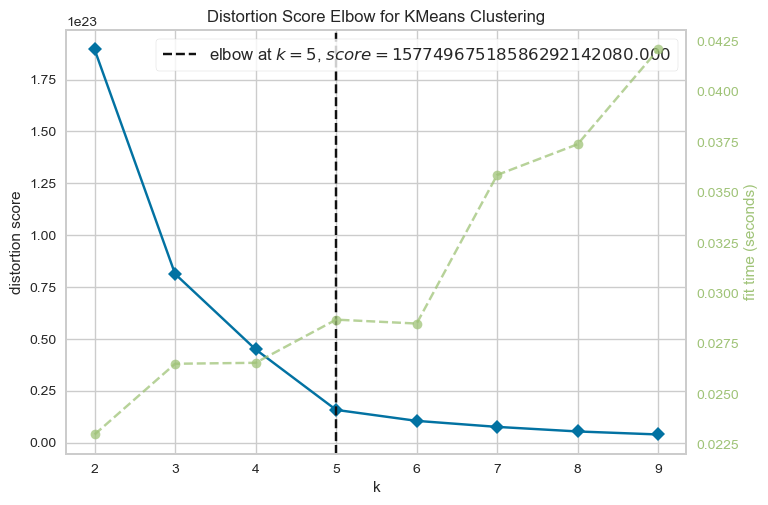

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [21]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['OS', 'event_OS']]], axis=1)
    coxph.fit(X_cluster, duration_col='OS', event_col='event_OS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 0: Most important feature: glcm_Contrast_d_1_CT_b20, Coefficient: -3.702891198946261


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 1: Most important feature: glcm_Idm_d_1_CT_c16, Coefficient: 1.593383671067269


...

Cluster 2: Most important feature: glrlm_ShortRunLowGrayLevelEmphasis_CT_b20, Coefficient: -1.0801505642152553


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 3: Most important feature: glszm_ZoneVariance_PET_c04, Coefficient: 3.5615909508432053


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 4: Most important feature: first_order_Mean_PET, Coefficient: -3.687910246534004


In [22]:
X_fs_fi = X.loc[:, selected_features]
X_new = X_fs_fi.copy()

# Standardization

In [23]:
# Do the standardization for X_fs_fi
scaler = StandardScaler() 
X_new_std= scaler.fit_transform(X_fs_fi)
X_new_std = pd.DataFrame(X_new_std,
                        columns=X_fs_fi.columns, 
                        index=X_fs_fi.index)

# Do the standardization for MAASTRO 
MAASTRO_new = X_MAASTRO[selected_features]
MAASTRO_new_std = scaler.transform(MAASTRO_new)
MAASTRO_new_std = pd.DataFrame(MAASTRO_new_std, 
                              columns=MAASTRO_new.columns, 
                              index=MAASTRO_new.index )

In [24]:
X_new

,glcm_Contrast_d_1_CT_b20,glcm_Idm_d_1_CT_c16,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20,glszm_ZoneVariance_PET_c04,first_order_Mean_PET
0,6.886589,0.840101,0.000536,1.219531e+06,7.489228
1,8.920914,0.825663,0.001324,4.304124e+04,3.236345
2,6.980935,0.896630,0.000455,3.413819e+06,4.223322
3,11.631134,0.791167,0.000847,8.781387e+04,1.952779
4,19.329411,0.728472,0.001143,8.861450e+04,3.774285
...,...,...,...,...,...
134,1.815042,0.821965,0.001070,3.597457e+05,4.805702
135,3.764694,0.951673,0.000553,2.965962e+06,4.700546
136,7.349739,0.883420,0.000739,1.391820e+06,6.798946
137,1.546743,0.885885,0.000770,1.381604e+06,4.828376


In [25]:
X_new_std

,glcm_Contrast_d_1_CT_b20,glcm_Idm_d_1_CT_c16,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20,glszm_ZoneVariance_PET_c04,first_order_Mean_PET
0,-0.282561,-0.341440,-0.355813,-0.119028,0.571369
1,-0.090013,-0.568573,-0.057949,-0.134949,-1.034766
2,-0.273631,0.547838,-0.386438,-0.089333,-0.662026
3,0.166509,-1.111247,-0.238230,-0.134343,-1.519515
4,0.895150,-2.097532,-0.126201,-0.134332,-0.831609
...,...,...,...,...,...
134,-0.762582,-0.626752,-0.153755,-0.130663,-0.442086
135,-0.578048,1.413759,-0.349547,-0.095394,-0.481799
136,-0.238724,0.340038,-0.279216,-0.116696,0.310679
137,-0.787977,0.378815,-0.267222,-0.116835,-0.433523


In [26]:
MAASTRO_new

,glcm_Contrast_d_1_CT_b20,glcm_Idm_d_1_CT_c16,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20,glszm_ZoneVariance_PET_c04,first_order_Mean_PET
0,3.639734,0.933581,0.000574,4.428071e+06,8.620975
1,10.777475,0.938549,0.002657,2.882700e+06,3.833351
2,6.252600,0.909791,0.000617,2.022118e+06,6.182864
3,34.958124,0.806769,0.005186,9.767851e+05,4.199987
4,2.617836,0.905080,0.000393,3.380150e+06,4.872122
...,...,...,...,...,...
94,12.670929,0.913855,0.000635,1.025170e+06,13.222061
95,30.996676,0.795492,0.003568,3.175732e+06,5.751008
96,5.425459,0.883448,0.000344,8.932914e+06,4.613887
97,5.927237,0.882436,0.000467,3.790488e+06,6.385348


In [27]:
MAASTRO_new_std

,glcm_Contrast_d_1_CT_b20,glcm_Idm_d_1_CT_c16,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20,glszm_ZoneVariance_PET_c04,first_order_Mean_PET
0,-0.589876,1.129144,-0.341595,-0.075608,0.998783
1,0.085711,1.207286,0.446245,-0.096521,-0.809302
2,-0.342568,0.754883,-0.325268,-0.108167,0.078010
3,2.374405,-0.865808,1.402805,-0.122313,-0.670839
4,-0.686598,0.680778,-0.410016,-0.089789,-0.417002
...,...,...,...,...,...
94,0.264926,0.818819,-0.318427,-0.121658,2.736419
95,1.999455,-1.043207,0.790942,-0.092555,-0.085083
96,-0.420857,0.340473,-0.428448,-0.014645,-0.514526
97,-0.373364,0.324553,-0.381884,-0.084236,0.154480


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [28]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-19 14:30:11,188] A new study created in memory with name: no-name-1723deaf-445c-4ec9-8b51-6a29ad542278


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-19 14:30:11,498] A new study created in memory with name: no-name-51b353c8-bfc2-479f-9653-328c601604b3


Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7232142857142857
Fold 3 C-index: 0.4852941176470588
Fold 4 C-index: 0.5274261603375527
Fold 5 C-index: 0.4788732394366197
[I 2024-04-19 14:30:11,492] Trial 0 finished with value: 0.5589788766444194 and parameters: {}. Best is trial 0 with value: 0.5589788766444194.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5589788766444194], datetime_start=datetime.datetime(2024, 4, 19, 14, 30, 11, 276865), datetime_complete=datetime.datetime(2024, 4, 19, 14, 30, 11, 492572), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5589788766444194


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.22490670981166688
Fold 2 IBS: 0.21144123839174922
Fold 3 IBS: 0.1978242746350829
Fold 4 IBS: 0.20858468435485616
Fold 5 IBS: 0.22586741117179723
[I 2024-04-19 14:30:11,779] Trial 0 finished with value: 0.2137248636730305 and parameters: {}. Best is trial 0 with value: 0.2137248636730305.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2137248636730305], datetime_start=datetime.datetime(2024, 4, 19, 14, 30, 11, 530823), datetime_complete=datetime.datetime(2024, 4, 19, 14, 30, 11, 779704), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2137248636730305


In [29]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [30]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.559
train_ibs:  0.214


#### Test

In [31]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [32]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.542
IBS score: 0.231


In [33]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [34]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [35]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 14:30:11,940] A new study created in memory with name: no-name-94d62603-be31-48be-a724-95fa3d8d9def


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6515151515151515
Fold 2 C-index: 0.5669642857142857
Fold 3 C-index: 0.49264705882352944
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.5070422535211268
[I 2024-04-19 14:30:12,086] Trial 0 finished with value: 0.5710599102523715 and parameters: {}. Best is trial 0 with value: 0.5710599102523715.


[I 2024-04-19 14:30:12,095] A new study created in memory with name: no-name-1c7dbd3b-0e6a-47a1-95e9-c7422fc774bc




* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5710599102523715], datetime_start=datetime.datetime(2024, 4, 19, 14, 30, 11, 969627), datetime_complete=datetime.datetime(2024, 4, 19, 14, 30, 12, 86233), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5710599102523715


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397651960124292
Fold 2 IBS: 0.22157791679403802
Fold 3 IBS: 0.20453594470407013
Fold 4 IBS: 0.22473794971736924
Fold 5 IBS: 0.2181243144575922
[I 2024-04-19 14:30:12,277] Trial 0 finished with value: 0.2165905290548625 and parameters: {}. Best is trial 0 with value: 0.2165905290548625.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2165905290548625], datetime_start=datetime.datetime(2024, 4, 19, 14, 30, 12, 133066), datetime_complete=datetime.datetime(2024, 4, 19, 14, 30, 12, 277753), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2165905290548625


In [36]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [37]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.571
train_ibs:  0.217


#### Test

In [38]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [39]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.571


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [40]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [41]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 14:30:12,442] A new study created in memory with name: no-name-fa937602-c64f-4092-9a84-6e0442491e39


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7232142857142857
Fold 3 C-index: 0.47549019607843135
Fold 4 C-index: 0.5316455696202531
Fold 5 C-index: 0.4788732394366197

[I 2024-04-19 14:30:12,825] A new study created in memory with name: no-name-03e8c091-0197-4d9e-bdf7-ab2cff74db10



[I 2024-04-19 14:30:12,809] Trial 0 finished with value: 0.557861974187234 and parameters: {}. Best is trial 0 with value: 0.557861974187234.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.557861974187234], datetime_start=datetime.datetime(2024, 4, 19, 14, 30, 12, 477024), datetime_complete=datetime.datetime(2024, 4, 19, 14, 30, 12, 808579), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.557861974187234


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2243507078569092
Fold 2 IBS: 0.2112844845212529
Fold 3 IBS: 0.19782550040835672
Fold 4 IBS: 0.2077434313803298
Fold 5 IBS: 0.22546168983790887
[I 2024-04-19 14:30:13,354] Trial 0 finished with value: 0.21333316280095146 and parameters: {}. Best is trial 0 with value: 0.21333316280095146.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21333316280095146], datetime_start=datetime.datetime(2024, 4, 19, 14, 30, 12, 875345), datetime_complete=datetime.datetime(2024, 4, 19, 14, 30, 13, 354432), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21333316280095146


In [42]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [43]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.558
train_ibs:  0.213


#### Test

In [44]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [45]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.542


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.231


In [46]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [47]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 14:30:13,895] A new study created in memory with name: no-name-6ddae164-7b78-4472-a01a-415ff61a0d45


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7232142857142857
Fold 3 C-index: 0.47549019607843135
Fold 4 C-index: 0.5316455696202531
Fold 5 C-index: 0.4788732394366197
[I 2024-04-19 14:30:14,295] Trial 0 finished with value: 0.557861974187234 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.557861974187234.
Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7232142857142857
Fold 3 C-index: 0.4852941176470588
Fold 4 C-index: 0.5316455696202531
Fold 5 C-index: 0.4788732394366197
[I 2024-04-19 14:30:14,510] Trial 1 finished with value: 0.5598227585009595 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.5598227585009595.
Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7232142857142857
Fold 3 C-index: 0.4852941176470588
Fold 4 C-index: 0.5274261603375527
Fold 5 C-index: 0.4788732394366197
[I 2024-04-19 14:30:14,803] Trial 2 finished with value: 0.5589788766444194 and parameters: {'l1_ratio': 0.22692876841884668}. 

Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7232142857142857
Fold 3 C-index: 0.4852941176470588
Fold 4 C-index: 0.5316455696202531
Fold 5 C-index: 0.4788732394366197
[I 2024-04-19 14:30:18,967] Trial 25 finished with value: 0.5598227585009595 and parameters: {'l1_ratio': 0.35097283989684885}. Best is trial 13 with value: 0.6186575425158637.
Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7232142857142857
Fold 3 C-index: 0.4852941176470588
Fold 4 C-index: 0.5274261603375527
Fold 5 C-index: 0.4788732394366197
[I 2024-04-19 14:30:19,259] Trial 26 finished with value: 0.5589788766444194 and parameters: {'l1_ratio': 0.20309773550305477}. Best is trial 13 with value: 0.6186575425158637.
Fold 1 C-index: 0.658008658008658
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.4852941176470588
Fold 4 C-index: 0.5274261603375527
Fold 5 C-index: 0.4788732394366197
[I 2024-04-19 14:30:19,472] Trial 27 finished with value: 0.5888490065145493 and parameters: {'l1_ratio': 0.09486155085202

Fold 2 C-index: 0.7232142857142857
Fold 3 C-index: 0.4803921568627451
Fold 4 C-index: 0.5316455696202531
Fold 5 C-index: 0.4788732394366197
[I 2024-04-19 14:30:23,905] Trial 49 finished with value: 0.5588423663440968 and parameters: {'l1_ratio': 0.4477016529538363}. Best is trial 13 with value: 0.6186575425158637.
Fold 1 C-index: 0.658008658008658
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.5049019607843137
Fold 4 C-index: 0.6329113924050633
Fold 5 C-index: 0.4788732394366197
[I 2024-04-19 14:30:24,033] Trial 50 finished with value: 0.6138676215555023 and parameters: {'l1_ratio': 0.048267837521436346}. Best is trial 13 with value: 0.6186575425158637.
Fold 1 C-index: 0.658008658008658
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.5049019607843137
Fold 4 C-index: 0.6286919831223629
Fold 5 C-index: 0.5070422535211268
[I 2024-04-19 14:30:24,119] Trial 51 finished with value: 0.6186575425158637 and parameters: {'l1_ratio': 0.006012843953331914}. Best is trial 13 with value: 

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.22439195832917705
Fold 2 IBS: 0.2113061286512664
Fold 3 IBS: 0.19782177581496319
Fold 4 IBS: 0.2077907230006835
Fold 5 IBS: 0.22545399562038634
[I 2024-04-19 14:30:32,232] Trial 0 finished with value: 0.21335291628329528 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.21335291628329528.
Fold 1 IBS: 0.2245240907304781
Fold 2 IBS: 0.21136889374751702
Fold 3 IBS: 0.19781080736892553
Fold 4 IBS: 0.20788576396237723
Fold 5 IBS: 0.22547737421414227
[I 2024-04-19 14:30:32,471] Trial 1 finished with value: 0.213413386004688 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.21335291628329528.
Fold 1 IBS: 0.2245464476110919
Fold 2 IBS: 0.21138246758737592
Fold 3 IBS: 0.19780796540459605
Fold 4 IBS: 0.20790805738203835
Fold 5 IBS: 0.22549514431547316
[I 2024-04-19 14:30:32,698] Trial 2 finished with value: 0.21342801646011508 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.213352916283295

Fold 1 IBS: 0.22438434343016006
Fold 2 IBS: 0.21128940897808282
Fold 3 IBS: 0.1978227197338559
Fold 4 IBS: 0.20778736110647217
Fold 5 IBS: 0.22546995343506038
[I 2024-04-19 14:30:38,041] Trial 25 finished with value: 0.2133507573367263 and parameters: {'l1_ratio': 0.7847459123468501}. Best is trial 14 with value: 0.21303343057025112.
Fold 1 IBS: 0.22434891080512384
Fold 2 IBS: 0.2112861959467852
Fold 3 IBS: 0.19782492008869232
Fold 4 IBS: 0.20773735667451834
Fold 5 IBS: 0.22545180423619468
[I 2024-04-19 14:30:38,251] Trial 26 finished with value: 0.21332983755026286 and parameters: {'l1_ratio': 0.9167426588025347}. Best is trial 14 with value: 0.21303343057025112.
Fold 1 IBS: 0.22438965691183546
Fold 2 IBS: 0.21130715721780685
Fold 3 IBS: 0.19782029216443958
Fold 4 IBS: 0.2077831876102035
Fold 5 IBS: 0.22547891601665382
[I 2024-04-19 14:30:38,460] Trial 27 finished with value: 0.21335584198418783 and parameters: {'l1_ratio': 0.6413089463704016}. Best is trial 14 with value: 0.213033430

Fold 4 IBS: 0.20799455761498406
Fold 5 IBS: 0.22549384377733359
[I 2024-04-19 14:30:43,070] Trial 50 finished with value: 0.21346512277943713 and parameters: {'l1_ratio': 0.14873903489612597}. Best is trial 44 with value: 0.21285810952387788.
Fold 1 IBS: 0.21316441740920908
Fold 2 IBS: 0.22142947892139794
Fold 3 IBS: 0.20364803562681708
Fold 4 IBS: 0.20776805674911553
Fold 5 IBS: 0.22550221840235768
[I 2024-04-19 14:30:43,195] Trial 51 finished with value: 0.21430244142177943 and parameters: {'l1_ratio': 0.04368256890256818}. Best is trial 44 with value: 0.21285810952387788.
Fold 1 IBS: 0.21306912686407112
Fold 2 IBS: 0.22141053007244357
Fold 3 IBS: 0.2035454177541148
Fold 4 IBS: 0.20763551041695588
Fold 5 IBS: 0.22551408200186038
[I 2024-04-19 14:30:43,351] Trial 52 finished with value: 0.21423493342188915 and parameters: {'l1_ratio': 0.05044361443405454}. Best is trial 44 with value: 0.21285810952387788.
Fold 1 IBS: 0.22463010331487093
Fold 2 IBS: 0.21144577307049928
Fold 3 IBS: 0.19

Fold 1 IBS: 0.2127249419299876
Fold 2 IBS: 0.22134004804760665
Fold 3 IBS: 0.1977989993815133
Fold 4 IBS: 0.2071213221577228
Fold 5 IBS: 0.2254872369840368
[I 2024-04-19 14:30:48,262] Trial 76 finished with value: 0.21289450970017346 and parameters: {'l1_ratio': 0.07951104999526773}. Best is trial 44 with value: 0.21285810952387788.
Fold 1 IBS: 0.21269568623519372
Fold 2 IBS: 0.22133393865864603
Fold 3 IBS: 0.19779963897377267
Fold 4 IBS: 0.20805293740737735
Fold 5 IBS: 0.22549772089973602
[I 2024-04-19 14:30:48,472] Trial 77 finished with value: 0.21307598443494516 and parameters: {'l1_ratio': 0.08239939603227674}. Best is trial 44 with value: 0.21285810952387788.
Fold 1 IBS: 0.21397075889731726
Fold 2 IBS: 0.2215769539676131
Fold 3 IBS: 0.20452953481316238
Fold 4 IBS: 0.22451281424842956
Fold 5 IBS: 0.21812235806959224
[I 2024-04-19 14:30:48,595] Trial 78 finished with value: 0.21654248399922293 and parameters: {'l1_ratio': 0.00024550177478210866}. Best is trial 44 with value: 0.2128

In [48]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [49]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.619
train_ibs:  0.213


#### Test

In [50]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [51]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.004533920544850127)

test_cindex : 0.572


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.038174725697405855)

test_ibs:  0.221


In [52]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [53]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-19 14:30:51,843] A new study created in memory with name: no-name-9bc2c72f-31f2-4bbd-ab74-6fb06de8b1fd


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7209821428571429
Fold 3 C-index: 0.5735294117647058
Fold 4 C-index: 0.6160337552742616
Fold 5 C-index: 0.5586854460093896
[I 2024-04-19 14:30:54,437] Trial 0 finished with value: 0.6055344628694116 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6055344628694116.
Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.6785714285714286
Fold 3 C-index: 0.5637254901960784
Fold 4 C-index: 0.6286919831223629
Fold 5 C-index: 0.5492957746478874
[I 2024-04-19 14:30:56,056] Trial 1 finished with value: 0.5879530392036554 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 

Fold 1 C-index: 0.5324675324675324
Fold 2 C-index: 0.8415178571428571
Fold 3 C-index: 0.6102941176470589
Fold 4 C-index: 0.6582278481012658
Fold 5 C-index: 0.6126760563380281
[I 2024-04-19 14:31:21,680] Trial 16 finished with value: 0.6510366823393484 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 15, 'min_samples_leaf': 16, 'max_depth': 1, 'n_estimators': 88, 'oob_score': True, 'max_samples': 0.8360998471106429, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.08633662845826989, 'warm_start': True}. Best is trial 14 with value: 0.6914566183853726.
Fold 1 C-index: 0.5844155844155844
Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.5955882352941176
Fold 4 C-index: 0.6286919831223629
Fold 5 C-index: 0.5704225352112676
[I 2024-04-19 14:31:21,802] Trial 17 finished with value: 0.641002239037238 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 15, 'min_samples_leaf': 19, 'max_depth': 1, 'n_estimators': 8, 'oob_score': True, 'max_samples': 0.8699768148803853, '

Fold 1 C-index: 0.5367965367965368
Fold 2 C-index: 0.8348214285714286
Fold 3 C-index: 0.7892156862745098
Fold 4 C-index: 0.7932489451476793
Fold 5 C-index: 0.755868544600939
[I 2024-04-19 14:31:30,040] Trial 31 finished with value: 0.7419902282782187 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 13, 'min_samples_leaf': 4, 'max_depth': 8, 'n_estimators': 117, 'oob_score': True, 'max_samples': 0.8845777475441136, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.11294999839255701, 'warm_start': True}. Best is trial 28 with value: 0.7690969773945008.
Fold 1 C-index: 0.5627705627705628
Fold 2 C-index: 0.8236607142857143
Fold 3 C-index: 0.6274509803921569
Fold 4 C-index: 0.7046413502109705
Fold 5 C-index: 0.6525821596244131
[I 2024-04-19 14:31:30,577] Trial 32 finished with value: 0.6742211534567635 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 14, 'min_samples_leaf': 5, 'max_depth': 9, 'n_estimators': 111, 'oob_score': True, 'max_samples': 0.8916303549631995, 

...

Fold 1 IBS: 0.21997918958835128
Fold 2 IBS: 0.18587466302626318
Fold 3 IBS: 0.2004784637666396
Fold 4 IBS: 0.2123758892169664
Fold 5 IBS: 0.22609793094043296
[I 2024-04-19 14:34:42,604] Trial 32 finished with value: 0.20896122730773067 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 9, 'min_samples_leaf': 15, 'max_depth': 5, 'n_estimators': 81, 'oob_score': False, 'max_samples': 0.7410372124157341, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.06827975804476301}. Best is trial 25 with value: 0.20847412028457124.
Fold 1 IBS: 0.22359237419788744
Fold 2 IBS: 0.18680600164923428
Fold 3 IBS: 0.1984542625323854
Fold 4 IBS: 0.2189038456335693
Fold 5 IBS: 0.22479486104218618
[I 2024-04-19 14:34:44,126] Trial 33 finished with value: 0.21051026901105252 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 10, 'min_samples_leaf': 13, 'max_depth': 5, 'n_estimators': 41, 'oob_score': False, 'max_samples': 0.711470805152538, 'max_features': 'auto', 'min_weight_fraction_leaf'

Fold 1 IBS: 0.21399417282658154
Fold 2 IBS: 0.22174351634097914
Fold 3 IBS: 0.20490570412404543
Fold 4 IBS: 0.22489050239521194
Fold 5 IBS: 0.218463760240665
[I 2024-04-19 14:35:28,041] Trial 48 finished with value: 0.2167995311854966 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 8, 'min_samples_leaf': 13, 'max_depth': 7, 'n_estimators': 148, 'oob_score': False, 'max_samples': 0.5606440507914384, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.33444361706095027}. Best is trial 25 with value: 0.20847412028457124.
Fold 1 IBS: 0.22884222130033388
Fold 2 IBS: 0.19164507126951885
Fold 3 IBS: 0.20025956907162223
Fold 4 IBS: 0.21148496820561993
Fold 5 IBS: 0.2263356496384803
[I 2024-04-19 14:35:36,242] Trial 49 finished with value: 0.21171349589711505 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 14, 'min_samples_leaf': 12, 'max_depth': 2, 'n_estimators': 403, 'oob_score': False, 'max_samples': 0.8870683341680491, 'max_features': 'auto', 'min_weight_fraction_l

Fold 1 IBS: 0.21684031025918443
Fold 2 IBS: 0.18584612981268436
Fold 3 IBS: 0.20127706431508158
Fold 4 IBS: 0.21401762536111155
Fold 5 IBS: 0.22680714479720884
[I 2024-04-19 14:36:16,361] Trial 64 finished with value: 0.20895765490905416 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 10, 'min_samples_leaf': 13, 'max_depth': 10, 'n_estimators': 82, 'oob_score': False, 'max_samples': 0.4972021450036761, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.09198556938666305}. Best is trial 25 with value: 0.20847412028457124.
Fold 1 IBS: 0.21620945461003296
Fold 2 IBS: 0.19224538384597223
Fold 3 IBS: 0.20285176672708838
Fold 4 IBS: 0.21604014638841687
Fold 5 IBS: 0.22458092750943495
[I 2024-04-19 14:36:20,037] Trial 65 finished with value: 0.21038553581618907 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 10, 'min_samples_leaf': 13, 'max_depth': 10, 'n_estimators': 152, 'oob_score': False, 'max_samples': 0.4728664986432956, 'max_features': 'auto', 'min_weight_fract

Fold 5 IBS: 0.21279811760139627
[I 2024-04-19 14:36:47,441] Trial 79 finished with value: 0.2071749195176274 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 12, 'min_samples_leaf': 19, 'max_depth': 17, 'n_estimators': 10, 'oob_score': True, 'max_samples': 0.45906720021070324, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.1222353656460299}. Best is trial 69 with value: 0.20671852829719137.
Fold 1 IBS: 0.23097298405940805
Fold 2 IBS: 0.18357621341529434
Fold 3 IBS: 0.22638565714678177
Fold 4 IBS: 0.22268916113980045
Fold 5 IBS: 0.2131316345430238
[I 2024-04-19 14:36:48,038] Trial 80 finished with value: 0.21535113006086165 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 12, 'min_samples_leaf': 19, 'max_depth': 18, 'n_estimators': 2, 'oob_score': True, 'max_samples': 0.44870459090875026, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.14398035145985677}. Best is trial 69 with value: 0.20671852829719137.
Fold 1 IBS: 0.2134452735216979
Fold 2 IBS: 0.19012

Fold 1 IBS: 0.23348698771238932
Fold 2 IBS: 0.18401552557976522
Fold 3 IBS: 0.19312430557833157
Fold 4 IBS: 0.21833741018584218
Fold 5 IBS: 0.22704672475334658
[I 2024-04-19 14:37:36,736] Trial 95 finished with value: 0.21120219076193497 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 11, 'min_samples_leaf': 1, 'max_depth': 12, 'n_estimators': 24, 'oob_score': False, 'max_samples': 0.5739374614153154, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.09822433265023267}. Best is trial 69 with value: 0.20671852829719137.
Fold 1 IBS: 0.21618378323993317
Fold 2 IBS: 0.18725287003226745
Fold 3 IBS: 0.2067450282937796
Fold 4 IBS: 0.21734159577924983
Fold 5 IBS: 0.23031584725802035
[I 2024-04-19 14:37:39,323] Trial 96 finished with value: 0.21156782492065007 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 15, 'min_samples_leaf': 15, 'max_depth': 13, 'n_estimators': 98, 'oob_score': False, 'max_samples': 0.5145227129901372, 'max_features': None, 'min_weight_fraction_

In [54]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [55]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.804
train_ibs:  0.207


#### Test

In [56]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [57]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=20, max_features=None, max_leaf_nodes=14,
                     max_samples=0.965348734977708, min_samples_split=3,
                     min_weight_fraction_leaf=0.028577173994904947,
                     n_estimators=54, random_state=123, warm_start=True)

test_cindex:  0.573


RandomSurvivalForest(max_depth=12, max_features='log2', max_leaf_nodes=10,
                     max_samples=0.4469194930028868, min_samples_leaf=12,
                     min_samples_split=5,
                     min_weight_fraction_leaf=6.299528207963175e-05,
                     n_estimators=49, random_state=123)

test_ibs:  0.219


In [58]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [59]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 14:37:49,206] A new study created in memory with name: no-name-f7d68298-9ed2-462d-8634-c4489425b982


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.8214285714285714
Fold 3 C-index: 0.6470588235294118
Fold 4 C-index: 0.620253164556962
Fold 5 C-index: 0.6150234741784038
[I 2024-04-19 14:37:51,154] Trial 0 finished with value: 0.6567701227559859 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6567701227559859.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 14:37:59,583] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}

Fold 5 C-index: 0.5821596244131455
[I 2024-04-19 14:39:07,912] Trial 15 finished with value: 0.6329674199782508 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.6808227853208739.
Fold 1 C-index: 0.5844155844155844
Fold 2 C-index: 0.8125
Fold 3 C-index: 0.5220588235294118
Fold 4 C-index: 0.6033755274261603
Fold 5 C-index: 0.5375586854460094
[I 2024-04-19 14:39:10,095] Trial 16 finished with value: 0.6119817241634331 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction_leaf': 0.4093818399278544}. Best is trial 12 with value: 0.6808227853208739.
Fold

Fold 5 C-index: 0.5938967136150235
[I 2024-04-19 14:39:28,513] Trial 30 finished with value: 0.627386774475913 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 3, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 219, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.6295056648198173, 'min_weight_fraction_leaf': 0.2986752385567662}. Best is trial 12 with value: 0.6808227853208739.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 14:39:29,118] Trial 31 finished with value: 0.5 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 5, 'min_samples_leaf': 6, 'max_depth': 16, 'n_estimators': 10, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.9466810137420434, 'min_weight_fraction_leaf': 0.3745055741924508}. Best is trial 12 with value: 0.6808227853208739.
Fold 1 C-index: 0.6471861471861472
Fold 2 C-index: 0.8571428571428571
Fold 3 C-index: 

...

Fold 1 IBS: 0.20954840116811022
Fold 2 IBS: 0.21516867787827304
Fold 3 IBS: 0.20633410370973823
Fold 4 IBS: 0.217443753759578
Fold 5 IBS: 0.21760939950122515
[I 2024-04-19 14:44:50,113] Trial 30 finished with value: 0.21322086720338493 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 2, 'n_estimators': 161, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.885290333130627, 'min_weight_fraction_leaf': 0.17141436902843765}. Best is trial 24 with value: 0.21124285800033382.
Fold 1 IBS: 0.20916557303191124
Fold 2 IBS: 0.21077258158822984
Fold 3 IBS: 0.20751765532522876
Fold 4 IBS: 0.21203007176997968
Fold 5 IBS: 0.21672011866781823
[I 2024-04-19 14:44:56,124] Trial 31 finished with value: 0.21124120007663355 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 20, 'min_samples_leaf': 6, 'max_depth': 12, 'n_estimators': 317, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.89

Fold 1 IBS: 0.21369740882666785
Fold 2 IBS: 0.21820450973934133
Fold 3 IBS: 0.20395755917507463
Fold 4 IBS: 0.2192229186879461
Fold 5 IBS: 0.21801765605035947
[I 2024-04-19 14:46:10,981] Trial 45 finished with value: 0.21462001049587784 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 18, 'min_samples_leaf': 2, 'max_depth': 19, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.7956999786640259, 'min_weight_fraction_leaf': 0.05732819481246795}. Best is trial 43 with value: 0.2105439276591407.
Fold 1 IBS: 0.21332201907876833
Fold 2 IBS: 0.21969459644064773
Fold 3 IBS: 0.20441090789055072
Fold 4 IBS: 0.22232846642384665
Fold 5 IBS: 0.21813957340638512
[I 2024-04-19 14:46:17,105] Trial 46 finished with value: 0.2155791126480397 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 17, 'min_samples_leaf': 2, 'max_depth': 15, 'n_estimators': 389, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.9543894

Fold 1 IBS: 0.21397014451257237
Fold 2 IBS: 0.22126181390646826
Fold 3 IBS: 0.20484972560738754
Fold 4 IBS: 0.2246080695607368
Fold 5 IBS: 0.218601702151275
[I 2024-04-19 14:47:26,939] Trial 60 finished with value: 0.21665829114768798 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 14, 'min_samples_leaf': 7, 'max_depth': 11, 'n_estimators': 417, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.4494775780741444, 'min_weight_fraction_leaf': 0.4524120602521908}. Best is trial 50 with value: 0.20849484768889087.
Fold 1 IBS: 0.21035667905286487
Fold 2 IBS: 0.20613255922737753
Fold 3 IBS: 0.20434039699043846
Fold 4 IBS: 0.20922740276925214
Fold 5 IBS: 0.219288548372058
[I 2024-04-19 14:47:32,920] Trial 61 finished with value: 0.20986911728239818 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 8, 'n_estimators': 357, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.60433632

Fold 1 IBS: 0.2101185730624017
Fold 2 IBS: 0.20658994462751437
Fold 3 IBS: 0.20391352774324148
Fold 4 IBS: 0.20947342382148265
Fold 5 IBS: 0.2204310175335485
[I 2024-04-19 14:49:00,486] Trial 75 finished with value: 0.21010529735763775 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 18, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 438, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.3773641964039798, 'min_weight_fraction_leaf': 0.0005178936982578805}. Best is trial 50 with value: 0.20849484768889087.
Fold 1 IBS: 0.2080229161859106
Fold 2 IBS: 0.2107887246314857
Fold 3 IBS: 0.202755856516763
Fold 4 IBS: 0.21282189980626495
Fold 5 IBS: 0.2157371762857343
[I 2024-04-19 14:49:09,230] Trial 76 finished with value: 0.21002531468523172 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 466, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.44375

Fold 1 IBS: 0.20964271523302863
Fold 2 IBS: 0.20900485791123377
Fold 3 IBS: 0.20249322776110293
Fold 4 IBS: 0.21764668563444725
Fold 5 IBS: 0.2160243788462765
[I 2024-04-19 14:50:15,397] Trial 90 finished with value: 0.2109623730772178 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 19, 'min_samples_leaf': 1, 'max_depth': 16, 'n_estimators': 103, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.24265240403018676, 'min_weight_fraction_leaf': 0.0644410749305858}. Best is trial 84 with value: 0.20826489027595815.
Fold 1 IBS: 0.20783437735910332
Fold 2 IBS: 0.2020221327916416
Fold 3 IBS: 0.20549512306984768
Fold 4 IBS: 0.20902676876754495
Fold 5 IBS: 0.22067021724126706
[I 2024-04-19 14:50:17,225] Trial 91 finished with value: 0.20900972384588093 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 18, 'min_samples_leaf': 1, 'max_depth': 13, 'n_estimators': 65, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.4975

In [60]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [61]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.725
train_ibs:  0.204


#### Test

In [62]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [63]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=6, max_leaf_nodes=5,
                   max_samples=0.9434057215372886, min_samples_leaf=2,
                   min_samples_split=2,
                   min_weight_fraction_leaf=0.010174357714718953,
                   n_estimators=243, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.605


ExtraSurvivalTrees(max_depth=13, max_features=None, max_leaf_nodes=18,
                   max_samples=0.5923806266085482, min_samples_leaf=2,
                   min_samples_split=2,
                   min_weight_fraction_leaf=0.08785505320348544, n_estimators=4,
                   random_state=123, warm_start=True)

IBS: 0.226


In [64]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [65]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-19 14:50:27,331] A new study created in memory with name: no-name-1ebee7fe-7f66-4bbd-96e4-e4f7f2e2abe9


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 14:51:01,785] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 14:51:21,060] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 14:59:26,112] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.7784830438231676, 'learning_rate': 0.02439641670004065, 'dropout_rate': 0.4821375662037144, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 6.245821408640139, 'min_weight_fraction_leaf': 0.3469021849356369, 'max_features': 1, 'min_impurity_decrease': 0.002901900339595834, 'validation_fraction': 0.40492470595401014, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 9 with value: 0.6245455023287131.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 15:00:42,305] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.5522283925781899, 'learning_rate': 0.010913227078192221, 'dropout_rate': 0.275468298707492, 'n_estimators': 392, 'criterion': 'squared_error', 'c

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 15:08:50,551] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8806073308147355, 'learning_rate': 0.022376976197093057, 'dropout_rate': 0.6881130985931054, 'n_estimators': 424, 'criterion': 'squared_error', 'ccp_alpha': 2.7801390404743485, 'min_weight_fraction_leaf': 0.14826348238129222, 'max_features': 1, 'min_impurity_decrease': 3.2746646321179855e-06, 'validation_fraction': 0.654336976255422, 'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 5}. Best is trial 9 with value: 0.6245455023287131.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 15:10:01,189] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.6416570269538786, 'learning_rate': 0.08875752985571464, 'dropout_rate': 0.19627515205758927, 'n_estimators': 344, 'criterion': 'friedman_mse'

...

Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-19 16:09:57,143] Trial 45 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5303064017076159, 'learning_rate': 0.013591809817627606, 'dropout_rate': 0.4506745791740544, 'n_estimators': 401, 'criterion': 'friedman_mse', 'ccp_alpha': 2.5557833119257145, 'min_weight_fraction_leaf': 0.3344828403640176, 'max_features': 0.1, 'min_impurity_decrease': 0.02254931450703544, 'validation_fraction': 0.5042239156018957, 'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 15, 'max_depth': 14}. Best is trial 9 with value: 0.2165440709811577.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-19 16:10:30,961] Trial 46 finished with value: 0.21659054862241586 and parameters: {'subsam

Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-19 16:14:33,873] Trial 56 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.1173095704794419, 'learning_rate': 0.022797925457682687, 'dropout_rate': 0.2500192595896841, 'n_estimators': 209, 'criterion': 'squared_error', 'ccp_alpha': 1.515994978548666, 'min_weight_fraction_leaf': 0.04557038009296144, 'max_features': 'sqrt', 'min_impurity_decrease': 8.288990661784225e-06, 'validation_fraction': 0.6682715637714014, 'min_samples_split': 13, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 7}. Best is trial 9 with value: 0.2165440709811577.
Fold 1 IBS: 0.21380708638179544
Fold 2 IBS: 0.22152033052173714
Fold 3 IBS: 0.20441674084580197
Fold 4 IBS: 0.2245566429057011
Fold 5 IBS: 0.21813859683868578
[I 2024-04-19 16:14:54,230] Trial 57 finished with value: 0.2164878794987443 and parameters: {'subsample': 0.553868700002313, 'le

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-19 16:21:25,794] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.44533772449036413, 'learning_rate': 0.0814448088163274, 'dropout_rate': 0.8313520760085876, 'n_estimators': 440, 'criterion': 'friedman_mse', 'ccp_alpha': 0.5496755232313972, 'min_weight_fraction_leaf': 0.23846073397265538, 'max_features': 'log2', 'min_impurity_decrease': 0.0245829172127866, 'validation_fraction': 0.8751349059723512, 'min_samples_split': 17, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 4}. Best is trial 63 with value: 0.21620881142774429.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609574
[I 2024-04-19 16:22:05,853] Trial 68 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.49945879365729917, 'learning_rate': 0.0790496181988

Fold 3 IBS: 0.20409996067955558
Fold 4 IBS: 0.2242561647915901
Fold 5 IBS: 0.21816454577723815
[I 2024-04-19 16:27:55,256] Trial 78 finished with value: 0.21617880533533582 and parameters: {'subsample': 0.3352733938121141, 'learning_rate': 0.07411999177509665, 'dropout_rate': 0.8605229004531987, 'n_estimators': 473, 'criterion': 'squared_error', 'ccp_alpha': 0.023234528924181166, 'min_weight_fraction_leaf': 0.20870378808533252, 'max_features': 'log2', 'min_impurity_decrease': 0.007686471270079544, 'validation_fraction': 0.6325076348170467, 'min_samples_split': 19, 'max_leaf_nodes': 14, 'min_samples_leaf': 11, 'max_depth': 5}. Best is trial 75 with value: 0.2160195904582106.
Fold 1 IBS: 0.21368511643230517
Fold 2 IBS: 0.22104421619565023
Fold 3 IBS: 0.20419020892086942
Fold 4 IBS: 0.2243449916768901
Fold 5 IBS: 0.2180695509291797
[I 2024-04-19 16:28:08,599] Trial 79 finished with value: 0.21626681683097893 and parameters: {'subsample': 0.33166032751272273, 'learning_rate': 0.07500771068

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-19 16:30:48,057] Trial 89 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.40845912170347753, 'learning_rate': 0.07409455257113193, 'dropout_rate': 0.9031580025226588, 'n_estimators': 489, 'criterion': 'squared_error', 'ccp_alpha': 1.426169496743956, 'min_weight_fraction_leaf': 0.17670307432796536, 'max_features': 'log2', 'min_impurity_decrease': 0.001833888378396466, 'validation_fraction': 0.7135149436193794, 'min_samples_split': 20, 'max_leaf_nodes': 13, 'min_samples_leaf': 13, 'max_depth': 3}. Best is trial 75 with value: 0.2160195904582106.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20452888336445285
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609557
[I 2024-04-19 16:31:08,329] Trial 90 finished with value: 0.21658913583127015 and parameters: {'subsample': 0.2452119153654136, 'learning_rate': 0.0669096549840

In [66]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [67]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.625
train_ibs:  0.216


#### Test

In [68]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [69]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.07426378544613033,
                                 criterion='squared_error',
                                 dropout_rate=0.28125955124323376,
                                 learning_rate=0.013102111413618,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=1.4994028685178666e-07,
                                 min_samples_leaf=10,
                                 min_weight_fraction_leaf=0.27579636299120275,
                                 n_estimators=406, random_state=123,
                                 subsample=0.6059965408578151,
                                 validation_fraction=0.6359003593513561)

C-index score: 0.554


GradientBoostingSurvivalAnalysis(ccp_alpha=0.009365616677551508,
                                 dropout_rate=0.7826693566389662,
                                 learning_rate=0.08843409287484169, max_depth=4,
                                 max_features='log2', max_leaf_nodes=14,
                                 min_impurity_decrease=0.0008096076350961149,
                                 min_samples_leaf=16, min_samples_split=19,
                                 min_weight_fraction_leaf=0.2812508412156809,
                                 n_estimators=403, random_state=123,
                                 subsample=0.5200735929114648,
                                 validation_fraction=0.7004324115891782)

IBS: 0.221


In [70]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [71]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 16:34:50,624] A new study created in memory with name: no-name-5e67b676-0562-49a9-b10e-7b131902919e


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6666666666666666
Fold 2 C-index: 0.8303571428571429
Fold 3 C-index: 0.49019607843137253
Fold 4 C-index: 0.6329113924050633
Fold 5 C-index: 0.5023474178403756
[I 2024-04-19 16:34:52,025] Trial 0 finished with value: 0.6244957396401242 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6244957396401242.
Fold 1 C-index: 0.6666666666666666
Fold 2 C-index: 0.8303571428571429
Fold 3 C-index: 0.49019607843137253
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.5023474178403756
[I 2024-04-19 16:35:02,894] Trial 1 finished with value: 0.6253396214966643 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.6253396214966643.
Fold 1 C-index: 0.658008658008658
Fold 2 C-index: 0.8169642857142857
Fold 3 C-index: 0.49019607843137253
Fol

Fold 1 C-index: 0.6666666666666666
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.49019607843137253
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.5023474178403756
[I 2024-04-19 16:36:13,944] Trial 19 finished with value: 0.6199824786395214 and parameters: {'subsample': 0.765021860726683, 'dropout_rate': 0.6297730339074776, 'n_estimators': 174, 'learning_rate': 0.08697733590757546}. Best is trial 1 with value: 0.6253396214966643.
Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.7901785714285714
Fold 3 C-index: 0.49019607843137253
Fold 4 C-index: 0.6286919831223629
Fold 5 C-index: 0.49765258215962443
[I 2024-04-19 16:36:23,321] Trial 20 finished with value: 0.6068849685695118 and parameters: {'subsample': 0.38161734041406226, 'dropout_rate': 0.3658150689038728, 'n_estimators': 447, 'learning_rate': 0.017331004877487094}. Best is trial 1 with value: 0.6253396214966643.
Fold 1 C-index: 0.6666666666666666
Fold 2 C-index: 0.8169642857142857
Fold 3 C-index: 0.4901960784313725

Fold 1 C-index: 0.670995670995671
Fold 2 C-index: 0.7901785714285714
Fold 3 C-index: 0.4950980392156863
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.5023474178403756
[I 2024-04-19 16:36:43,379] Trial 38 finished with value: 0.6199939820901537 and parameters: {'subsample': 0.8454052791269616, 'dropout_rate': 0.1479392437629521, 'n_estimators': 48, 'learning_rate': 0.07253056054066635}. Best is trial 25 with value: 0.6288247439691286.
Fold 1 C-index: 0.6623376623376623
Fold 2 C-index: 0.8214285714285714
Fold 3 C-index: 0.49019607843137253
Fold 4 C-index: 0.6329113924050633
Fold 5 C-index: 0.5023474178403756
[I 2024-04-19 16:36:44,126] Trial 39 finished with value: 0.6218442244886091 and parameters: {'subsample': 0.6823027480266115, 'dropout_rate': 0.21911905294320408, 'n_estimators': 91, 'learning_rate': 0.08658997521969063}. Best is trial 25 with value: 0.6288247439691286.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.8080357142857143
Fold 3 C-index: 0.49019607843137253
F

...

Fold 4 IBS: 0.20407705732189668
Fold 5 IBS: 0.21734619955825263
[I 2024-04-19 16:39:29,913] Trial 19 finished with value: 0.21156762258236833 and parameters: {'subsample': 0.8350722272141606, 'dropout_rate': 0.19352385445052883, 'n_estimators': 43, 'learning_rate': 0.01832204160528565}. Best is trial 15 with value: 0.20951860494791621.
Fold 1 IBS: 0.2139648454963244
Fold 2 IBS: 0.22157008247590007
Fold 3 IBS: 0.20447997329194048
Fold 4 IBS: 0.22328440874354324
Fold 5 IBS: 0.21810917026729268
[I 2024-04-19 16:39:30,312] Trial 20 finished with value: 0.21628169605500017 and parameters: {'subsample': 0.6343904688286152, 'dropout_rate': 0.11035756162962672, 'n_estimators': 8, 'learning_rate': 0.0016589351820883932}. Best is trial 15 with value: 0.20951860494791621.
Fold 1 IBS: 0.21089986518017273
Fold 2 IBS: 0.22048503027443145
Fold 3 IBS: 0.20450026162261206
Fold 4 IBS: 0.19477719940000957
Fold 5 IBS: 0.21844069056515142
[I 2024-04-19 16:39:31,449] Trial 21 finished with value: 0.20982060

Fold 4 IBS: 0.23743415612154292
Fold 5 IBS: 0.2262805259710201
[I 2024-04-19 16:40:02,026] Trial 38 finished with value: 0.22417097345653483 and parameters: {'subsample': 0.5527084253035235, 'dropout_rate': 0.14183092515497794, 'n_estimators': 132, 'learning_rate': 0.07288612365177065}. Best is trial 32 with value: 0.2095083807869834.
Fold 1 IBS: 0.2104837532575219
Fold 2 IBS: 0.219261023695129
Fold 3 IBS: 0.2041214003451449
Fold 4 IBS: 0.1960075504127607
Fold 5 IBS: 0.21739772368602517
[I 2024-04-19 16:40:02,736] Trial 39 finished with value: 0.20945429027931634 and parameters: {'subsample': 0.761239885964328, 'dropout_rate': 0.47513976884315723, 'n_estimators': 60, 'learning_rate': 0.04737875306285835}. Best is trial 39 with value: 0.20945429027931634.
Fold 1 IBS: 0.21979456796374766
Fold 2 IBS: 0.2392123025836166
Fold 3 IBS: 0.30473018729197904
Fold 4 IBS: 0.3101631986423037
Fold 5 IBS: 0.2910107176707662
[I 2024-04-19 16:40:10,417] Trial 40 finished with value: 0.2729821948304826 a

Fold 4 IBS: 0.19808739834508335
Fold 5 IBS: 0.21777864234681982
[I 2024-04-19 16:40:24,149] Trial 57 finished with value: 0.20977571148854354 and parameters: {'subsample': 0.39366942237552593, 'dropout_rate': 0.49895200229993864, 'n_estimators': 117, 'learning_rate': 0.03011815188063965}. Best is trial 42 with value: 0.20921500515413277.
Fold 1 IBS: 0.21218179789350336
Fold 2 IBS: 0.21945464585903784
Fold 3 IBS: 0.20305716382580807
Fold 4 IBS: 0.19607333021089143
Fold 5 IBS: 0.21816963348756563
[I 2024-04-19 16:40:24,867] Trial 58 finished with value: 0.2097873142553613 and parameters: {'subsample': 0.4678960796610994, 'dropout_rate': 0.5462080102365253, 'n_estimators': 70, 'learning_rate': 0.06229645328036418}. Best is trial 42 with value: 0.20921500515413277.
Fold 1 IBS: 0.21208540849978333
Fold 2 IBS: 0.21881408643584072
Fold 3 IBS: 0.20156270511384122
Fold 4 IBS: 0.19819951566584615
Fold 5 IBS: 0.21765978077788245
[I 2024-04-19 16:40:25,987] Trial 59 finished with value: 0.20966429

Fold 1 IBS: 0.21215465217935014
Fold 2 IBS: 0.21970320619510927
Fold 3 IBS: 0.2023351350552351
Fold 4 IBS: 0.19574449424093418
Fold 5 IBS: 0.21745716469838774
[I 2024-04-19 16:40:50,101] Trial 77 finished with value: 0.2094789304738033 and parameters: {'subsample': 0.7050506533068872, 'dropout_rate': 0.6981056962456518, 'n_estimators': 55, 'learning_rate': 0.047560480403971414}. Best is trial 42 with value: 0.20921500515413277.
Fold 1 IBS: 0.21212859181479118
Fold 2 IBS: 0.21734202451195056
Fold 3 IBS: 0.20304904779813548
Fold 4 IBS: 0.19803726445476263
Fold 5 IBS: 0.219831407920293
[I 2024-04-19 16:40:50,966] Trial 78 finished with value: 0.2100776672999866 and parameters: {'subsample': 0.425627116582431, 'dropout_rate': 0.6992044818233512, 'n_estimators': 91, 'learning_rate': 0.060603706284811876}. Best is trial 42 with value: 0.20921500515413277.
Fold 1 IBS: 0.2270177183466651
Fold 2 IBS: 0.24309805006628407
Fold 3 IBS: 0.28955851221170076
Fold 4 IBS: 0.3078691610454465
Fold 5 IBS: 

Fold 1 IBS: 0.21143325392252751
Fold 2 IBS: 0.21941926496082167
Fold 3 IBS: 0.2030978989578912
Fold 4 IBS: 0.19627190572427494
Fold 5 IBS: 0.21771023594082242
[I 2024-04-19 16:41:23,683] Trial 97 finished with value: 0.20958651190126756 and parameters: {'subsample': 0.6603912608219311, 'dropout_rate': 0.7535730623581146, 'n_estimators': 47, 'learning_rate': 0.06470684027515988}. Best is trial 83 with value: 0.20921027950331667.
Fold 1 IBS: 0.21353952779346955
Fold 2 IBS: 0.22154540144257345
Fold 3 IBS: 0.2045045993108887
Fold 4 IBS: 0.21213019722266754
Fold 5 IBS: 0.21804690425504103
[I 2024-04-19 16:41:24,004] Trial 98 finished with value: 0.21395332600492808 and parameters: {'subsample': 0.6987254145088165, 'dropout_rate': 0.8180061555522371, 'n_estimators': 1, 'learning_rate': 0.059333461906187296}. Best is trial 83 with value: 0.20921027950331667.
Fold 1 IBS: 0.21069795527383847
Fold 2 IBS: 0.21961239026804316
Fold 3 IBS: 0.20769886599638177
Fold 4 IBS: 0.19586471075363157
Fold 5 I

In [72]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [73]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.632
train_ibs:  0.209


#### Test

In [74]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [75]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.45965924173632877,
                                              learning_rate=0.07611815005614658,
                                              n_estimators=12, random_state=123,
                                              subsample=0.7932220322549535)

C-index score: 0.572


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.8379931546434596,
                                              learning_rate=0.05807299897230618,
                                              n_estimators=54, random_state=123,
                                              subsample=0.6801785327842476)

IBS: 0.219


In [76]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [77]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.804,1.0
ExtraSurvivalTrees,0.725,2.0
ComponentwiseGradientBoosting,0.632,3.0
GradientBoosting,0.625,4.0
CoxElastic,0.619,5.0
CoxRidge,0.571,6.0
CoxPH,0.559,7.0
CoxLasso,0.558,8.0


In [78]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.204,1.0
Randomsurvivalforest,0.207,2.0
ComponentwiseGradientBoosting,0.209,3.0
CoxLasso,0.213,4.5
CoxElastic,0.213,4.5
CoxPH,0.214,6.0
GradientBoosting,0.216,7.0
CoxRidge,0.217,8.0


In [79]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.605,1.0
Randomsurvivalforest,0.573,2.0
CoxElastic,0.572,3.5
ComponentwiseGradientBoosting,0.572,3.5
CoxRidge,0.571,5.0
GradientBoosting,0.554,6.0
CoxPH,0.542,7.5
CoxLasso,0.542,7.5


In [80]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.219,1.5
ComponentwiseGradientBoosting,0.219,1.5
CoxRidge,0.221,4.0
CoxElastic,0.221,4.0
GradientBoosting,0.221,4.0
ExtraSurvivalTrees,0.226,6.0
CoxPH,0.231,7.5
CoxLasso,0.231,7.5


In [81]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d2/os/standard/fs_fi/' 

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d2_os_standard_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [82]:
from datetime import date

current_date = date.today()
print(current_date)

2024-04-19
